In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/data.csv")

df["TransactionStartTime"] = pd.to_datetime(
    df["TransactionStartTime"]
)

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0


In [3]:
snapshot_date = (
    df["TransactionStartTime"].max()
    + pd.Timedelta(days=1)
)

rfm = df.groupby("CustomerId").agg(
    Recency=(
        "TransactionStartTime",
        lambda x: (snapshot_date - x.max()).days
    ),
    Frequency=(
        "TransactionId",
        "count"
    ),
    Monetary=(
        "Amount",
        "sum"
    )
).reset_index()

rfm.head()

,CustomerId,Recency,Frequency,Monetary
0,CustomerId_1,84,1,-10000.0
1,CustomerId_10,84,1,-10000.0
2,CustomerId_1001,90,5,20000.0
3,CustomerId_1002,26,11,4225.0
4,CustomerId_1003,12,6,20000.0


In [4]:
rfm.describe()

,Recency,Frequency,Monetary
count,3742.000000,3742.000000,3.742000e+03
mean,31.461251,25.564404,1.717377e+05
std,27.118932,96.929602,2.717305e+06
min,1.000000,1.000000,-1.049000e+08
25%,6.000000,2.000000,4.077438e+03
50%,25.000000,7.000000,2.000000e+04
75%,54.000000,20.000000,7.996775e+04
max,91.000000,4091.000000,8.345124e+07


In [5]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[["Recency", "Frequency", "Monetary"]]
)

In [6]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(
    rfm_scaled
)

rfm.head()

,CustomerId,Recency,Frequency,Monetary,Cluster
0,CustomerId_1,84,1,-10000.0,0
1,CustomerId_10,84,1,-10000.0,0
2,CustomerId_1001,90,5,20000.0,0
3,CustomerId_1002,26,11,4225.0,1
4,CustomerId_1003,12,6,20000.0,1


In [7]:
rfm["Cluster"].value_counts()

Cluster
1    2315
0    1426
2       1
Name: count, dtype: int64

In [8]:
rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,61.877279,7.720196,8.172068e+04
1,12.726566,34.800000,2.725741e+05
2,29.000000,4091.000000,-1.049000e+08


In [19]:
high_risk_cluster = 2

In [20]:
rfm["is_high_risk"] = (
    rfm["Cluster"] == high_risk_cluster
).astype(int)

rfm.head()

,CustomerId,Recency,Frequency,Monetary,Cluster,is_high_risk
0,CustomerId_1,84,1,-10000.0,0,0
1,CustomerId_10,84,1,-10000.0,0,0
2,CustomerId_1001,90,5,20000.0,0,0
3,CustomerId_1002,26,11,4225.0,1,0
4,CustomerId_1003,12,6,20000.0,1,0


In [21]:
rfm["is_high_risk"].value_counts()

is_high_risk
0    3741
1       1
Name: count, dtype: int64

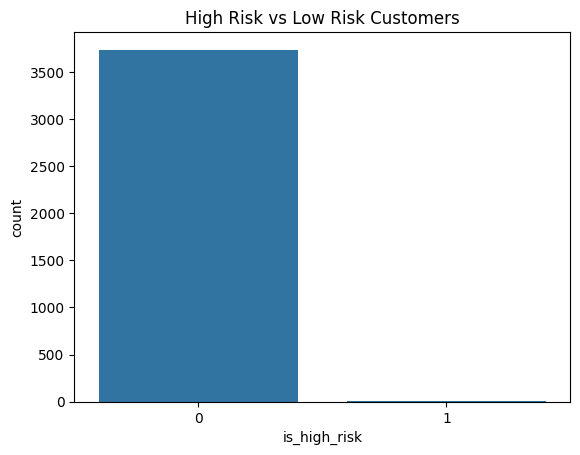

In [22]:
sns.countplot(
    x="is_high_risk",
    data=rfm
)

plt.title("High Risk vs Low Risk Customers")
plt.show()

# Top Insights

1. RFM analysis was used to represent customer behavior.

2. Customers were segmented into clusters using KMeans.

3. One cluster showed high recency and low transaction activity, indicating higher risk.

4. A proxy target variable (is_high_risk) was created for supervised modeling.

5. This target can now be used in Task 5 model training.

In [23]:
high_risk_cluster = 0

In [24]:
rfm["is_high_risk"] = (
    rfm["Cluster"] == high_risk_cluster
).astype(int)

rfm["is_high_risk"].value_counts()

is_high_risk
0    2316
1    1426
Name: count, dtype: int64

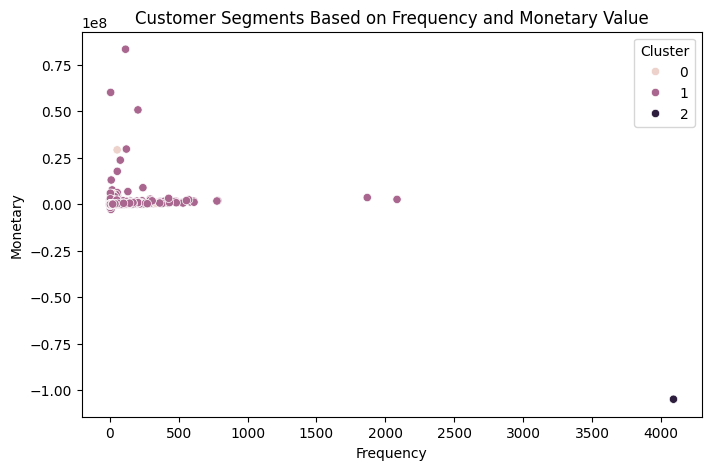

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster"
)

plt.title("Customer Segments Based on Frequency and Monetary Value")
plt.show()

### Cluster Interpretation

Cluster 0 exhibits the highest recency and relatively low transaction activity, indicating customers who have not engaged recently and may represent higher credit risk.

Cluster 1 contains active customers with frequent transactions and higher monetary value, representing lower risk.

Cluster 2 appears to contain extreme transaction behavior and may represent outliers or specialized customer segments.